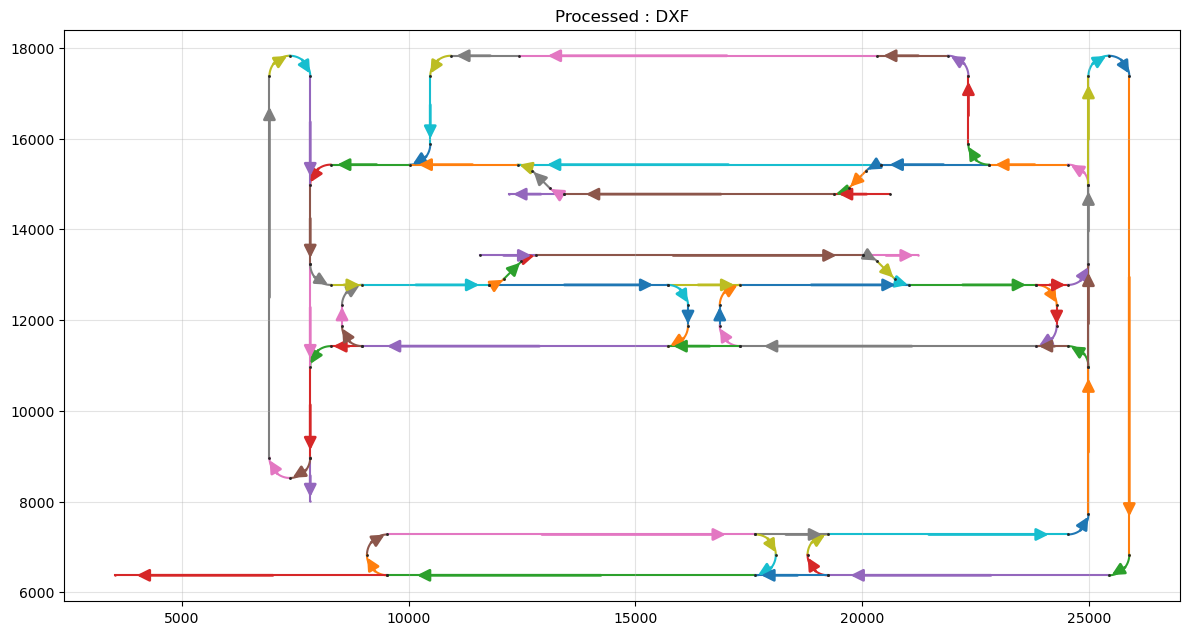

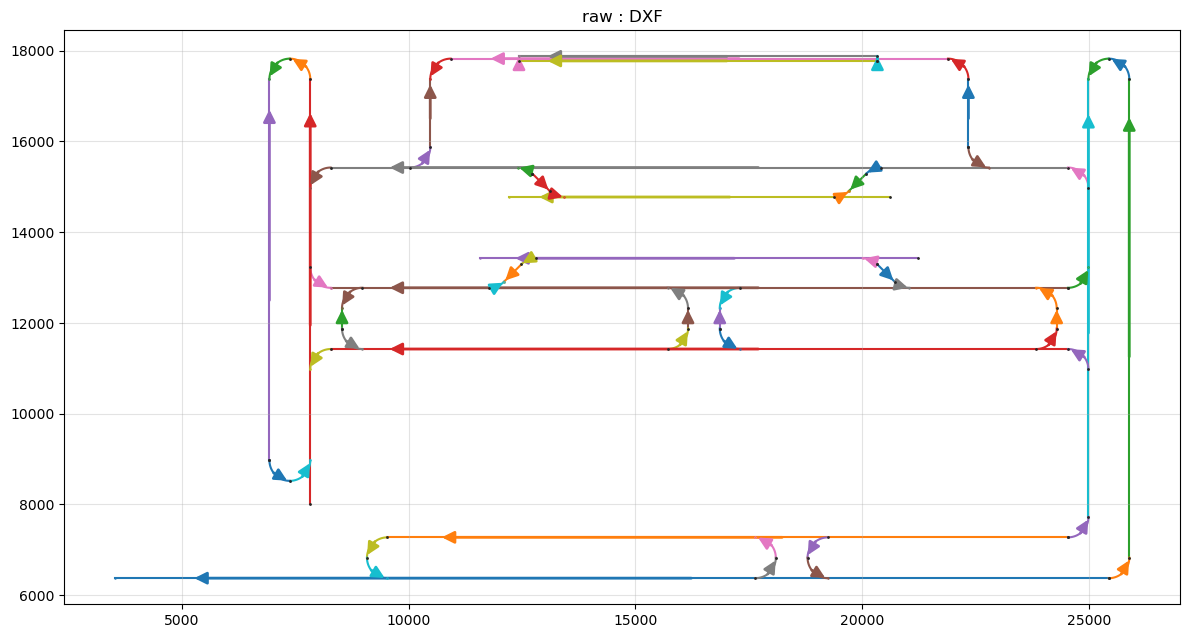

([MapNode(id='000001', type='G', reality='R', x='8300.000000', y='12800.000000', parent_link_id='', relative_distance='', reserved='', layer_id='0', pio_device_id='', param_disabled='', param_yield_enabled='0'),
  MapNode(id='000002', type='G', reality='R', x='22300.000000', y='15900.000000', parent_link_id='', relative_distance='', reserved='', layer_id='0', pio_device_id='', param_disabled='', param_yield_enabled='0'),
  MapNode(id='000003', type='G', reality='R', x='20300.000000', y='17800.000000', parent_link_id='', relative_distance='', reserved='', layer_id='0', pio_device_id='', param_disabled='', param_yield_enabled='0'),
  MapNode(id='000004', type='G', reality='R', x='9000.000000', y='11400.000000', parent_link_id='', relative_distance='', reserved='', layer_id='0', pio_device_id='', param_disabled='', param_yield_enabled='0'),
  MapNode(id='000005', type='G', reality='R', x='8500.000000', y='12300.000000', parent_link_id='', relative_distance='', reserved='', layer_id='0', p

In [2]:
from __future__ import annotations


"""testCad: DXF 분할/그래프/DFS — 완전한 방향 통일 로직"""


import math
from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional, Tuple
from collections import defaultdict  # deque — 미사용
import ezdxf
from ezdxf.math import Matrix44, Vec3
from ezdxf import disassemble
# import numpy as np  # 미사용
import matplotlib.pyplot as plt
# import matplotlib.cm as cm  # 미사용 (plt.cm 사용)

# -----------------------------
# 설정
# -----------------------------
# NDIGITS = 5  # 미사용
_base = Path.cwd()
DXF_PATH = _base / "Testbed1.dxf"
MAP_OUT = Path.cwd() / "Testbed1.map"


EPS = 1e-9
MIN_LINE_LENGTH = 0.0  # 모든 라인 포함

# 좌표 반올림 정밀도 (소수점 자릿수)
# - U/N 분기 판정은 접점/반지름 합 조건에 민감해서, 너무 미세한 소수 오차가 있으면 병합이 깨질 수 있음.
# - 예전 동작(정수 스냅)을 원복하려면 0으로 둔다.
SNAP_DECIMALS = 0  # 0이면 정수로 반올림

# 거리 기반 노드 병합 (0이면 비활성)
SNAP_TOL = 200.0  # 이 거리 이내의 점들을 하나로 병합

# 교차점 좌표 병합·분할 시 같은 점으로 볼 거리 (도면 단위)
INTER_MERGE_TOL = 100
SHORT_STRAIGHT_THRESHOLD = 900.0  # map_format 호-직-호 U분기 시 중간 직선 길이 상한


# -----------------------------
# 기본 유틸
# -----------------------------
# def _key_pt(p):
#     return (round(float(p[0]), 9), round(float(p[1]), 9))


def arc_point_at_deg(cx: float, cy: float, r: float, deg: float) -> Tuple[float, float]:
    a = math.radians(float(deg))
    return (float(cx) + float(r) * math.cos(a), float(cy) + float(r) * math.sin(a))

def arc_midpoint_from_dxf_angles(arc: "ArcSeg", cx: float, cy: float, r: float) -> Optional[Tuple[float, float]]:
    sa = getattr(arc, "dxf_start_deg", None)
    ea = getattr(arc, "dxf_end_deg", None)
    if sa is None or ea is None or r <= 1e-12:
        return None
    sweep = ccw_delta_deg(float(sa), float(ea))
    if sweep <= 1e-9:
        return None
    return arc_point_at_deg(cx, cy, r, float(sa) + 0.5 * sweep)

def arc_curve_midpoint(arc: "ArcSeg", cx: float, cy: float, r: float) -> Optional[Tuple[float, float]]:
    pm = getattr(arc, "p_mid_curve", None)
    if pm is not None:
        return (float(pm[0]), float(pm[1]))
    return arc_midpoint_from_dxf_angles(arc, cx, cy, r)

def split_near_180_arcs(arcs: List["ArcSeg"], *, target_deg: float = 180.0, tol_deg: float = 1.0) -> List["ArcSeg"]:
    out = []
    for arc in arcs:
        r = float(arc.r)
        if r <= 1e-12:
            out.append(arc)
            continue
        sa_raw = getattr(arc, "dxf_start_deg", None)
        ea_raw = getattr(arc, "dxf_end_deg", None)
        if sa_raw is not None and ea_raw is not None:
            sweep = ccw_delta_deg(float(sa_raw), float(ea_raw))
        else:
            sweep = ccw_delta_deg(float(arc.start_deg), float(arc.end_deg))
        minor_sweep = min(sweep, 360.0 - sweep)
        if abs(minor_sweep - float(target_deg)) > float(tol_deg):
            out.append(arc)
            continue
        pm = arc_curve_midpoint(arc, float(arc.cx), float(arc.cy), r)
        if pm is None or dist(pm, arc.p_start) <= INTER_MERGE_TOL * 0.02 or dist(pm, arc.p_end) <= INTER_MERGE_TOL * 0.02:
            out.append(arc)
            continue
        first = _arc_subsegment(arc, arc.p_start, pm)
        second = _arc_subsegment(arc, pm, arc.p_end)
        out.append(first)
        out.append(second)
    return out

    
def dist(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def ccw_delta_deg(a, b):
    """a에서 b까지 반시계 각도차 (0~360)."""
    return (b - a) % 360.0


def dxf_ccw_unwrap_end_deg(ta: float, tb: float) -> float:
    """CCW로 ta→tb일 때 선형 보간용 끝 각(도). ta+Δ로 unwrap (예: 350°→10°면 370°)."""
    return float(ta) + ccw_delta_deg(ta, tb)

# -----------------------------
# 교차 계산
# -----------------------------
def seg_intersection(p1, p2, p3, p4):
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3
    x4, y4 = p4

    den = (x1-x2)*(y3-y4) - (y1-y2)*(x3-x4)
    if abs(den) < EPS:
        return []

    t = ((x1-x3)*(y3-y4) - (y1-y3)*(x3-x4)) / den
    u = -((x1-x2)*(y1-y3) - (y1-y2)*(x1-x3)) / den

    if -1e-8 <= t <= 1+1e-8 and -1e-8 <= u <= 1+1e-8:
        return [(x1 + t*(x2-x1), y1 + t*(y2-y1))]
    return []

def _seg_param_t(a: Tuple[float, float], b: Tuple[float, float], p: Tuple[float, float]) -> float:
    dx, dy = b[0] - a[0], b[1] - a[1]
    L2 = dx * dx + dy * dy
    if L2 < EPS:
        return 0.0
    return ((p[0] - a[0]) * dx + (p[1] - a[1]) * dy) / L2

def _sort_dedupe_on_segment(
    a: Tuple[float, float],
    b: Tuple[float, float],
    pts: List[Tuple[float, float]],
    merge_tol: float,
) -> List[Tuple[float, float]]:
    items = []
    for p in pts:
        t = _seg_param_t(a, b, p)
        if -1e-6 <= t <= 1 + 1e-6:
            t = max(0.0, min(1.0, t))
            q = (a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1]))
            items.append((t, q))
    items.sort(key=lambda x: x[0])
    out: List[Tuple[float, float]] = []
    for _, q in items:
        if not out or dist(out[-1], q) > merge_tol:
            out.append(q)
    return out

def _line_seg_circle_hits(
    p1: Tuple[float, float],
    p2: Tuple[float, float],
    cx: float,
    cy: float,
    r: float,
) -> List[Tuple[float, float]]:
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    fx, fy = p1[0] - cx, p1[1] - cy
    a = dx * dx + dy * dy
    if a < EPS:
        return []
    b = 2 * (fx * dx + fy * dy)
    c0 = fx * fx + fy * fy - r * r
    disc = b * b - 4 * a * c0
    if disc < -1e-12:
        return []
    disc = max(0.0, disc)
    sqrt_d = math.sqrt(disc)
    out = []
    for sign in (-1.0, 1.0):
        t = (-b + sign * sqrt_d) / (2 * a)
        if -1e-9 <= t <= 1 + 1e-9:
            t = max(0.0, min(1.0, t))
            out.append((p1[0] + t * dx, p1[1] + t * dy))
    if len(out) == 2 and dist(out[0], out[1]) < INTER_MERGE_TOL:
        return [out[0]]
    return out

def _point_on_segment(p: Tuple[float, float], a: Tuple[float, float], b: Tuple[float, float], tol: float) -> bool:
    t = _seg_param_t(a, b, p)
    if not (-1e-9 <= t <= 1 + 1e-9):
        return False
    t = max(0.0, min(1.0, t))
    q = (a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1]))
    return dist(p, q) <= tol

def _closest_point_on_segment(p: Tuple[float, float], a: Tuple[float, float], b: Tuple[float, float]) -> Tuple[float, float]:
    """선분 AB 위에서 p에 가장 가까운 점(구간으로 클램프)."""
    t = _seg_param_t(a, b, p)
    t = max(0.0, min(1.0, t))
    return (a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1]))

def glue_arc_endpoints_to_lines(lines: List[LineSeg], arcs: List[ArcSeg], tol: float) -> None:
    """호 끝이 직선에 ‘거의’ 닿는데 끝점 스냅만으로는 안 붙는 경우:
    원 위에서 직선 쪽으로 끝을 옮기고, 해당 직선을 그 투영점에서 분할한다."""
    if tol <= 0:
        return
    min_seg = max(1e-6, tol * 0.02)
    for arc in arcs:
        if arc.r < 1e-12:
            continue
        for end_name in ("p_start", "p_end"):
            p = getattr(arc, end_name)
            best_q = None
            best_d = float("inf")
            best_idx = -1
            for i, seg in enumerate(lines):
                q = _closest_point_on_segment(p, seg.p1, seg.p2)
                d = dist(p, q)
                if d < best_d:
                    best_d, best_q, best_idx = d, q, i
            if best_d > tol or best_idx < 0 or best_q is None:
                continue
            ang = math.atan2(best_q[1] - arc.cy, best_q[0] - arc.cx)
            px = arc.cx + arc.r * math.cos(ang)
            py = arc.cy + arc.r * math.sin(ang)
            setattr(arc, end_name, (px, py))
            arc.start_deg = math.degrees(math.atan2(arc.p_start[1] - arc.cy, arc.p_start[0] - arc.cx)) % 360.0
            arc.end_deg = math.degrees(math.atan2(arc.p_end[1] - arc.cy, arc.p_end[0] - arc.cx)) % 360.0
            arc.p_mid_curve = None
            seg = lines[best_idx]
            split_pt = _closest_point_on_segment((px, py), seg.p1, seg.p2)
            if dist(seg.p1, split_pt) < min_seg or dist(seg.p2, split_pt) < min_seg:
                continue
            lines[best_idx : best_idx + 1] = [LineSeg(seg.p1, split_pt), LineSeg(split_pt, seg.p2)]

def split_arcs_at_line_intersections(arcs, line_edges, *, merge_tol=INTER_MERGE_TOL):
    """호를 라인과의 교차점에서 분할.
    각 호에 대해 라인들과의 교차점을 찾고, 호 위 순서로 정렬한 뒤 서브 세그먼트로 나눈다.
    """
    result = []
    for arc in arcs:
        if arc.r < 1e-12:
            result.append(arc)
            continue

        cuts = []
        for line in line_edges:
            for hit in _line_seg_circle_hits(line.p1, line.p2, arc.cx, arc.cy, arc.r):
                if not _on_arc_circle(hit, arc, merge_tol):
                    continue
                # 호 끝점과 너무 가까우면 스킵 (끝점 자체는 이미 연결됨)
                if dist(hit, arc.p_start) <= merge_tol or dist(hit, arc.p_end) <= merge_tol:
                    continue
                cuts.append(hit)

        if not cuts:
            result.append(arc)
            continue

        # 호 위 경로 순서로 정렬 후 중복 제거
        cuts = _sort_cuts_along_arc(arc, cuts, merge_tol)

        # p_start → cut₁ → cut₂ → ... → p_end 로 분할
        prev = arc.p_start
        for cut in cuts:
            if dist(prev, cut) > merge_tol:
                result.append(_arc_subsegment(arc, prev, cut))
            prev = cut
        if dist(prev, arc.p_end) > merge_tol:
            result.append(_arc_subsegment(arc, prev, arc.p_end))

    return result

def split_edges_at_intersections(
    line_list: List[LineSeg],
    arc_list: List[ArcSeg],
    *,
    merge_tol: float = INTER_MERGE_TOL,
) -> Tuple[List[LineSeg], List[ArcSeg], List[Tuple[float, float]]]:
    """LINE 분할: (1) 다른 LINE과의 교차 (2) 원호와 직선의 실교차 (3) 호 끝점이 직선 위에 있을 때.\n
    이후 직선과 교차하는 호를 교차점에서 ArcSeg 여러 개로 나눈다."""
    intersection_vertices: List[Tuple[float, float]] = []

    # 교차점 수가 많아지면 O(N^2) 중복 검사로 누락/느려짐이 생길 수 있어,
    # merge_near_points와 같은 방식(격자 버킷 + 인접 8칸 탐색)으로 교차점 병합.
    v_buckets: dict[Tuple[int, int], List[Tuple[float, float]]] = defaultdict(list)

    def _vkey(p: Tuple[float, float]) -> Tuple[int, int]:
        cell = max(float(merge_tol), 1e-9)
        return (int(math.floor(float(p[0]) / cell)), int(math.floor(float(p[1]) / cell)))

    def register_vertex(pt: Tuple[float, float]) -> None:
        g = _vkey(pt)
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for q in v_buckets.get((g[0] + dx, g[1] + dy), []):
                    if dist(pt, q) <= merge_tol:
                        return
        intersection_vertices.append(pt)
        v_buckets[g].append(pt)

    line_edges: List[LineSeg] = []

    for L in line_list:
        a, b = L.p1, L.p2
        cuts: List[Tuple[float, float]] = [a, b]

        for M in line_list:
            if M is L:
                continue
            c1, d1 = M.p1, M.p2
            for hit in seg_intersection(a, b, c1, d1):
                cuts.append(hit)
                register_vertex(hit)

        for arc in arc_list:
            if arc.r < 1e-12:
                continue

            for hit in _line_seg_circle_hits(a, b, arc.cx, arc.cy, arc.r):
                if _on_arc_circle(hit, arc, merge_tol):
                    cuts.append(hit)
                    register_vertex(hit)

            for ep in (arc.p_start, arc.p_end):
                if _point_on_segment(ep, a, b, merge_tol):
                    cuts.append(ep)
                    register_vertex(ep)

        chain = _sort_dedupe_on_segment(a, b, cuts, merge_tol)
        for k in range(len(chain) - 1):
            p, q = chain[k], chain[k + 1]
            if dist(p, q) > MIN_LINE_LENGTH:
                line_edges.append(LineSeg(p, q))

    new_arcs = split_arcs_at_line_intersections(arc_list, line_edges, merge_tol=merge_tol)
    return line_edges, new_arcs, intersection_vertices

# -----------------------------
# DXF 파싱
# -----------------------------
def arc_entity_endpoints_world_xy(arc_ent, m: Matrix44) -> Tuple[Tuple[float, float], Tuple[float, float]]:
    """ARC 끝점: ezdxf WCS(start_point/end_point, OCS·extrusion 반영) 후 블록 등 추가 변환 m."""
    s_w = m.transform(arc_ent.start_point)
    e_w = m.transform(arc_ent.end_point)
    return ((float(s_w.x), float(s_w.y)), (float(e_w.x), float(e_w.y)))

def transform_arc_to_xy(m: Matrix44, arc_ent):
    """중심은 OCS → WCS, 반지름·각은 WCS XY 투영(지도 평면)."""
    ocs = arc_ent.ocs()
    c = arc_ent.dxf.center
    zc = float(getattr(c, "z", 0) or 0)
    cc = Vec3(c.x, c.y, zc)
    c_w = m.transform(ocs.to_wcs(cc))
    s_w = m.transform(arc_ent.start_point)
    e_w = m.transform(arc_ent.end_point)
    r_w = math.hypot(s_w.x - c_w.x, s_w.y - c_w.y)
    sa_o = math.degrees(math.atan2(s_w.y - c_w.y, s_w.x - c_w.x))
    ea_o = math.degrees(math.atan2(e_w.y - c_w.y, e_w.x - c_w.x))
    return (c_w.x, c_w.y, r_w, sa_o, ea_o)

def arc_entity_midpoint_on_curve_world_xy(arc_ent, m: Matrix44) -> Optional[Tuple[float, float]]:
    """DXF가 실제로 그리는 호 위의 중간 점(ezdxf angles(3) 중간). 180° 반원 어느 쪽인지 구분용."""
    try:
        ag = list(arc_ent.angles(3))
        if len(ag) < 3:
            sa = float(arc_ent.dxf.start_angle)
            ea = float(arc_ent.dxf.end_angle)
            mid_a = (sa + ea) * 0.5
        else:
            mid_a = float(ag[1])
        v = list(arc_ent.vertices([mid_a]))[0]
        vw = m.transform(v)
        return (float(vw.x), float(vw.y))
    except Exception:
        return None

# -----------------------------
# DXF 수집용 세그먼트
# -----------------------------
@dataclass
class LineSeg:
    p1: Tuple[float, float]
    p2: Tuple[float, float]

@dataclass
class ArcSeg:
    cx: float
    cy: float
    r: float
    start_deg: float
    end_deg: float
    # 월드 XY에서 호의 시작·끝 (로컬 각도 점을 transform)
    p_start: Tuple[float, float] = (0.0, 0.0)
    p_end: Tuple[float, float] = (0.0, 0.0)
    # DXF 호의 실제 중간점 — 180°일 때 두 반원 중 어느 쪽인지 구분 (끝점 각만으로는 불가)
    p_mid_curve: Optional[Tuple[float, float]] = None
    # 원본 DXF(또는 분할 직후) 각도 스냅샷: glue/snap으로 끝점이 조금 움직여도 U 판별에 사용
    dxf_start_deg: Optional[float] = None
    dxf_end_deg: Optional[float] = None


def _arc_endpoint_degrees(arc: ArcSeg) -> Tuple[float, float]:
    ps, pe = arc.p_start, arc.p_end
    ts = math.degrees(math.atan2(ps[1] - arc.cy, ps[0] - arc.cx)) % 360.0
    te = math.degrees(math.atan2(pe[1] - arc.cy, pe[0] - arc.cx)) % 360.0
    return ts, te


def _arc_should_use_ccw_sweep(
    ts: float,
    te: float,
    L1: float,
    L2: float,
    cx: float,
    cy: float,
    r: float,
    pm: Optional[Tuple[float, float]],
) -> bool:
    """start→end로 그릴 때 CCW 스윕(L1)을 쓸지, CW(L2)를 쓸지.
    p_mid_curve가 있으면 각도 구간으로 어느 호에 속하는지 먼저 판별(중점 거리보다 안정적).
    없으면 두 끝 사이 짧은 호(L1<=L2면 CCW 방향이 짧음)."""
    if pm is not None:
        tp = math.degrees(math.atan2(pm[1] - cy, pm[0] - cx)) % 360.0
        eps = max(0.05, math.degrees(math.atan2(1e-6, max(r, 1e-12))))
        on_ccw = ccw_delta_deg(ts, tp) <= L1 + eps and ccw_delta_deg(tp, te) <= L1 + eps
        on_cw = ccw_delta_deg(te, tp) <= L2 + eps and ccw_delta_deg(tp, ts) <= L2 + eps
        if on_ccw and not on_cw:
            return True
        if on_cw and not on_ccw:
            return False
        mid_ccw_deg = (ts + 0.5 * L1) % 360.0
        mid_cw_deg = (ts - 0.5 * L2) % 360.0

        def _pt(deg: float) -> Tuple[float, float]:
            a = math.radians(deg)
            return (cx + r * math.cos(a), cy + r * math.sin(a))

        return dist(_pt(mid_ccw_deg), pm) <= dist(_pt(mid_cw_deg), pm)
    return L1 <= L2


def _on_arc_circle(pt: Tuple[float, float], arc: ArcSeg, tol: float) -> bool:
    """원 위 점이 실제로 그려진 호 위에 있는지."""
    r = arc.r
    if r < 1e-12:
        return False
    d = abs(dist((arc.cx, arc.cy), pt) - r)
    tol_r = max(tol, 1e-9 * max(r, 1.0))
    if d > tol_r:
        return False
    ts, te = _arc_endpoint_degrees(arc)
    tp = math.degrees(math.atan2(pt[1] - arc.cy, pt[0] - arc.cx)) % 360.0
    eps_deg = 1e-3 + math.degrees(math.atan2(tol_r, max(r, 1e-12)))
    L1 = ccw_delta_deg(ts, te)
    L2 = 360.0 - L1
    if L1 < 1e-9 or L2 < 1e-9:
        return dist(pt, arc.p_start) <= tol_r or dist(pt, arc.p_end) <= tol_r
    pm = getattr(arc, "p_mid_curve", None)
    if abs(L1 - L2) < 1e-6 and pm is not None:
        use_ccw = _arc_should_use_ccw_sweep(ts, te, L1, L2, arc.cx, arc.cy, arc.r, pm)
        if use_ccw:
            return ccw_delta_deg(ts, tp) <= L1 + eps_deg and ccw_delta_deg(tp, te) <= L1 + eps_deg
        return ccw_delta_deg(te, tp) <= L2 + eps_deg and ccw_delta_deg(tp, ts) <= L2 + eps_deg
    if abs(L1 - L2) < 1e-6:
        ok_a = ccw_delta_deg(ts, tp) <= L1 + eps_deg and ccw_delta_deg(tp, te) <= L1 + eps_deg
        ok_b = ccw_delta_deg(te, tp) <= L1 + eps_deg and ccw_delta_deg(tp, ts) <= L1 + eps_deg
        return ok_a or ok_b
    if L1 <= L2:
        return ccw_delta_deg(ts, tp) <= L1 + eps_deg and ccw_delta_deg(tp, te) <= L1 + eps_deg
    return ccw_delta_deg(te, tp) <= L2 + eps_deg and ccw_delta_deg(tp, ts) <= L2 + eps_deg

def _arc_sample_points_along_drawn(arc: ArcSeg, n: int = 64) -> List[Tuple[float, float]]:
    """실제로 그려진 호를 따라 start→end 순서 샘플 점 (_arc_xy_polyline과 동일 기준)."""
    cx, cy, r = float(arc.cx), float(arc.cy), float(arc.r)
    if r < 1e-12:
        return [arc.p_start, arc.p_end]
    ta = math.degrees(math.atan2(arc.p_start[1] - cy, arc.p_start[0] - cx)) % 360.0
    tb = math.degrees(math.atan2(arc.p_end[1] - cy, arc.p_end[0] - cx)) % 360.0
    L1 = ccw_delta_deg(ta, tb)
    L2 = 360.0 - L1
    pm = getattr(arc, "p_mid_curve", None)
    use_ccw = _arc_should_use_ccw_sweep(ta, tb, L1, L2, cx, cy, r, pm)
    out: List[Tuple[float, float]] = []
    for i in range(n + 1):
        t = i / n
        if use_ccw:
            end_ccw = dxf_ccw_unwrap_end_deg(ta, tb)
            ang_deg = ta + t * (end_ccw - ta)
        else:
            ang_deg = ta - t * L2
        ang = math.radians(ang_deg)
        out.append((cx + r * math.cos(ang), cy + r * math.sin(ang)))
    return out


def _sort_cuts_along_arc(arc: ArcSeg, cuts: List[Tuple[float, float]], merge_tol: float) -> List[Tuple[float, float]]:
    """교차점을 호 위 순서(start→end)로 정렬."""
    if not cuts:
        return []
    samples = _arc_sample_points_along_drawn(arc, n=96)
    scored: List[Tuple[float, int, float, Tuple[float, float]]] = []
    for p in cuts:
        best_i = 0
        best_d = float("inf")
        for i, q in enumerate(samples):
            d = dist(p, q)
            if d < best_d:
                best_d, best_i = d, i
        scored.append((best_i, best_d, float(p[0]), p))
    scored.sort(key=lambda x: (x[0], x[1], x[2]))
    return [t[3] for t in scored]


def _arc_subsegment(arc: ArcSeg, pa: Tuple[float, float], pb: Tuple[float, float]) -> ArcSeg:
    """부분 호: 끝점만 맞추고 p_mid_curve는 항상 설정 (L/R 판단 정확도를 위해).
    원본 호의 p_mid_curve를 기반으로 CCW/CW 방향을 판단해 서브 호의 중간점을 세팅한다."""
    cx, cy, r = float(arc.cx), float(arc.cy), float(arc.r)
    sa = math.degrees(math.atan2(pa[1] - cy, pa[0] - cx)) % 360.0
    ea = math.degrees(math.atan2(pb[1] - cy, pb[0] - cx)) % 360.0
    L1 = ccw_delta_deg(sa, ea)
    L2 = 360.0 - L1
    # 원본 호의 방향(CCW/CW) 계산
    orig_ta = math.degrees(math.atan2(arc.p_start[1] - cy, arc.p_start[0] - cx)) % 360.0
    orig_tb = math.degrees(math.atan2(arc.p_end[1] - cy, arc.p_end[0] - cx)) % 360.0
    orig_L1 = ccw_delta_deg(orig_ta, orig_tb)
    orig_L2 = 360.0 - orig_L1
    orig_pm = getattr(arc, "p_mid_curve", None)
    orig_use_ccw = _arc_should_use_ccw_sweep(orig_ta, orig_tb, orig_L1, orig_L2, cx, cy, r, orig_pm)
    # 서브 호도 같은 방향(CCW/CW)으로 중간점 계산 — p_mid_curve 항상 설정
    if orig_use_ccw:
        end_unwrap = sa + L1  # CCW
        mid_deg = (sa + 0.5 * L1) % 360.0
    else:
        mid_deg = (sa - 0.5 * L2) % 360.0
    mr = math.radians(mid_deg)
    pm_sub = (cx + r * math.cos(mr), cy + r * math.sin(mr))
    return ArcSeg(
        cx=cx,
        cy=cy,
        r=r,
        start_deg=sa,
        end_deg=ea,
        p_start=pa,
        p_end=pb,
        p_mid_curve=pm_sub,
        dxf_start_deg=sa,
        dxf_end_deg=ea,
    )


def _iter_insert_virtual_entities(insert_entity, *, max_depth: int = 20, depth: int = 0):
    """INSERT를 virtual_entities로 펼치고, 중첩 INSERT는 재귀한다. (ezdxf: WCS 기준)"""
    try:
        stream = insert_entity.virtual_entities()
    except Exception:
        return
    for ve in stream:
        if ve.dxftype() == "INSERT" and depth < max_depth:
            yield from _iter_insert_virtual_entities(ve, max_depth=max_depth, depth=depth + 1)
        else:
            yield ve


def collect_entities_recursive(doc) -> Tuple[List[LineSeg], List[ArcSeg]]:
    """모델공간 전체: LINE/ARC, LWPOLYLINE·POLYLINE(bulge→LINE/ARC 분해). INSERT는 virtual_entities(WCS)."""
    lines: List[LineSeg] = []
    arcs: List[ArcSeg] = []
    ident = Matrix44()

    def add_line_xy(p1, p2):
        if dist(p1, p2) > MIN_LINE_LENGTH:
            lines.append(LineSeg(p1, p2))

    def add_arc_wcs(arc_ent):
        p0, p1 = arc_entity_endpoints_world_xy(arc_ent, ident)
        cx, cy, r, sa, ea = transform_arc_to_xy(ident, arc_ent)
        pm = arc_entity_midpoint_on_curve_world_xy(arc_ent, ident)
        base_arc = ArcSeg(
            cx, cy, r, sa, ea,
            p_start=p0, p_end=p1,
            p_mid_curve=pm,
            dxf_start_deg=float(sa), dxf_end_deg=float(ea),
        )
        arcs.extend(split_near_180_arcs([base_arc], target_deg=180.0, tol_deg=1.0))

    def dispatch(ent):
        et = ent.dxftype()
        if et == "LINE":
            s, t = ent.dxf.start, ent.dxf.end
            add_line_xy((float(s.x), float(s.y)), (float(t.x), float(t.y)))
        elif et == "ARC":
            add_arc_wcs(ent)
        elif et == "LWPOLYLINE":
            from ezdxf.render.polyline import virtual_lwpolyline_entities
            for ve in virtual_lwpolyline_entities(ent):
                dispatch(ve)
        elif et == "POLYLINE":
            from ezdxf.render.polyline import virtual_polyline_entities
            for ve in virtual_polyline_entities(ent):
                if ve.dxftype() in ("LINE", "ARC"):
                    dispatch(ve)

    msp = doc.modelspace()
    for e in msp:
        if e.dxftype() == "INSERT":
            for ve in _iter_insert_virtual_entities(e):
                dispatch(ve)
        else:
            dispatch(e)
    return lines, arcs
# 가까운 노드(점) 병합 / 스냅
# -----------------------------
def _grid_key(p: Tuple[float, float], cell: float) -> Tuple[int, int]:
    if cell <= 0:
        return (0, 0)
    return (int(math.floor(p[0] / cell)), int(math.floor(p[1] / cell)))

def merge_near_points(points: List[Tuple[float, float]], tol: float) -> dict:
    """points의 각 점을 tol 이내 대표점으로 매핑."""
    if tol <= 0 or not points:
        return {p: p for p in points}

    cell = float(tol)
    buckets: dict[Tuple[int, int], List[Tuple[float, float]]] = defaultdict(list)
    reps: List[Tuple[float, float]] = []
    mapping: dict[Tuple[float, float], Tuple[float, float]] = {}

    for p in points:
        g = _grid_key(p, cell)
        best_rep = None
        best_d = None
        
        for dx in (-1, 0, 1):
            for dy in (-1, 0, 1):
                for r in buckets.get((g[0] + dx, g[1] + dy), []):
                    d = dist(p, r)
                    if d <= tol and (best_d is None or d < best_d):
                        best_rep, best_d = r, d

        if best_rep is None:
            reps.append(p)
            buckets[g].append(p)
            mapping[p] = p
        else:
            mapping[p] = best_rep

    return mapping

def snap_segments(split_lines: List[LineSeg], arcs: List[ArcSeg], tol: float) -> None:
    """세그먼트 좌표들을 tol 이내 대표점으로 in-place 치환."""
    if tol <= 0:
        return

    def _q(p: Tuple[float, float]) -> Tuple[float, float]:
        """좌표 양자화(정수/소수점). U/N 병합 안정화를 위해 스냅 전에 적용."""
        d = int(SNAP_DECIMALS) if "SNAP_DECIMALS" in globals() else 6
        if d <= 0:
            return (float(int(round(float(p[0])))), float(int(round(float(p[1])))))
        return (round(float(p[0]), d), round(float(p[1]), d))

    pts: List[Tuple[float, float]] = []

    # LINE 끝점을 먼저 넣어, tol 이내 병합 시 대표 좌표를 직선 쪽(p1/p2)으로 둔다.
    # (호 끝이 직선 쪽으로 당겨지면 snap 직후 원에서 벗을 수 있어 reproject_arcs_to_circle로 보정.)
    for s in split_lines:
        pts.append(_q(s.p1))
        pts.append(_q(s.p2))

    for a in arcs:
        pts.append(_q(a.p_start))
        pts.append(_q(a.p_end))

    # 중심/중간점은 마지막에 넣어도 무방 (필요 시에만)
    for a in arcs:
        pts.append(_q((a.cx, a.cy)))
        if getattr(a, "p_mid_curve", None) is not None:
            pts.append(_q(a.p_mid_curve))

    mp = merge_near_points(pts, tol)

    for s in split_lines:
        s.p1 = mp.get(_q(s.p1), _q(s.p1))
        s.p2 = mp.get(_q(s.p2), _q(s.p2))

    for a in arcs:
        a.p_start = mp.get(_q(a.p_start), _q(a.p_start))
        a.p_end = mp.get(_q(a.p_end), _q(a.p_end))
        c = mp.get(_q((a.cx, a.cy)), _q((a.cx, a.cy)))
        a.cx, a.cy = float(c[0]), float(c[1])
        if getattr(a, "p_mid_curve", None) is not None:
            pm = mp.get(_q(a.p_mid_curve), _q(a.p_mid_curve))
            ang = math.atan2(pm[1] - a.cy, pm[0] - a.cx)
            rr = max(a.r, 1e-12)
            a.p_mid_curve = (a.cx + rr * math.cos(ang), a.cy + rr * math.sin(ang))


def reproject_arcs_to_circle(arcs: List[ArcSeg]) -> None:
    """snap/glue 이후 스윕각 계산이 깨지는 문제를 방지.
    기존에는 p_start/p_end를 원 위로 재투영했는데,
    그 과정에서 '라인 끝점과 이미 병합된 접점'이 다시 어긋나는 문제가 생길 수 있다.
    여기서는 **끝점 좌표는 유지**하고, 각도(start/end_deg)만 현재 끝점 기준으로 재계산한다.
    """
    for a in arcs:
        if a.r < 1e-12:
            continue
        def _deg(p: Tuple[float, float]) -> float:
            return math.degrees(math.atan2(p[1] - a.cy, p[0] - a.cx)) % 360.0
        a.start_deg = _deg(a.p_start)
        a.end_deg = _deg(a.p_end)
        # 180° 모호성 해소용 중간점은 원 위에 두는 편이 안정적이라 투영 유지
        if getattr(a, "p_mid_curve", None) is not None:
            rr = float(max(a.r, 1e-12))
            pm = a.p_mid_curve
            ang = math.atan2(pm[1] - a.cy, pm[0] - a.cx)
            a.p_mid_curve = (a.cx + rr * math.cos(ang), a.cy + rr * math.sin(ang))

# -----------------------------
# 방향 통일 로직 (수정된 버전)
# -----------------------------
class Edge:
    def __init__(self, seg_data):
        if isinstance(seg_data, LineSeg):
            self.edge_type = 'LINE'
            self.start = seg_data.p1
            self.end = seg_data.p2
            self._data = seg_data
        elif isinstance(seg_data, ArcSeg):
            self.edge_type = 'ARC'
            self.start = seg_data.p_start
            self.end = seg_data.p_end
            self._data = seg_data
        else:
            raise ValueError("지원되지 않는 세그먼트 타입")
    
    def reverse(self):
        """엣지 방향 뒤집기"""
        self.start, self.end = self.end, self.start
        if isinstance(self._data, LineSeg):
            self._data.p1, self._data.p2 = self._data.p2, self._data.p1
        elif isinstance(self._data, ArcSeg):
            self._data.p_start, self._data.p_end = self._data.p_end, self._data.p_start
            self._data.start_deg, self._data.end_deg = self._data.end_deg, self._data.start_deg
    
    def chord_midpoint(self):
        """아크의 현(chord) 중점 — 방향 규칙에 사용"""
        if self.edge_type == 'ARC':
            return ((self.start[0] + self.end[0]) / 2, (self.start[1] + self.end[1]) / 2)
        return None
    
    def __repr__(self):
        return f"Edge({self.edge_type}, S={self.start}, E={self.end})"

# def build_adjacency_graph(edges, tolerance=INTER_MERGE_TOL):
#     """각 엣지의 end에서 연결되는 이웃만 저장"""
#     adj_graph = defaultdict(list)
#     
#     for i, edge in enumerate(edges):
#         for j, other_edge in enumerate(edges):
#             if i == j:
#                 continue
#             # i의 end와 j의 start 또는 end가 연결되는 경우만
#             if dist(edge.end, other_edge.start) <= tolerance or \
#                dist(edge.end, other_edge.end) <= tolerance:
#                 adj_graph[i].append(j)  # connection_point 없이 j만 저장
#     
#     return adj_graph

def get_direction_category(start_point, end_point):
    """방향 분류: right/left/up/down"""
    dx = end_point[0] - start_point[0]
    dy = end_point[1] - start_point[1]
    
    if abs(dx) >= abs(dy):
        return 'right' if dx >= 0 else 'left'
    else:
        return 'up' if dy >= 0 else 'down'

def apply_line_direction_rule(edge, prev_edge_end, tolerance=INTER_MERGE_TOL):
    """
    규칙 1: 라인 방향 통일
    이전 엣지와 만나는 점이 끝점이면 시작점이어야 하고, 시작점이면 끝점이어야 함
    """
    if edge.edge_type != 'LINE':
        return
    start_connects = dist(edge.start, prev_edge_end) <= tolerance
    end_connects = dist(edge.end, prev_edge_end) <= tolerance
    if end_connects and not start_connects:
        edge.reverse()


def _arc_tangent_unit_at_end_forward(arc_edge):
    """ARC start→end로 따라갈 때 끝점에서 나가는 단위 접선."""
    d = arc_edge._data
    px, py = float(arc_edge.end[0]), float(arc_edge.end[1])
    cx, cy = float(d.cx), float(d.cy)
    rx, ry = px - cx, py - cy
    ta = math.degrees(math.atan2(arc_edge.start[1] - cy, arc_edge.start[0] - cx)) % 360.0
    tb = math.degrees(math.atan2(arc_edge.end[1] - cy, arc_edge.end[0] - cx)) % 360.0
    L1 = ccw_delta_deg(ta, tb)
    L2 = 360.0 - L1
    pm = getattr(d, "p_mid_curve", None)
    ccw = _arc_should_use_ccw_sweep(ta, tb, L1, L2, cx, cy, d.r, pm)
    if ccw:
        tx, ty = -ry, rx
    else:
        tx, ty = ry, -rx
    mag = math.hypot(tx, ty)
    if mag < 1e-12:
        return (1.0, 0.0)
    return (tx / mag, ty / mag)


def _arc_tangent_unit_at_start_forward(arc_edge):
    """ARC start→end 진행 시 시작점에서의 단위 접선."""
    d = arc_edge._data
    px, py = float(arc_edge.start[0]), float(arc_edge.start[1])
    cx, cy = float(d.cx), float(d.cy)
    rx, ry = px - cx, py - cy
    ta = math.degrees(math.atan2(arc_edge.start[1] - cy, arc_edge.start[0] - cx)) % 360.0
    tb = math.degrees(math.atan2(arc_edge.end[1] - cy, arc_edge.end[0] - cx)) % 360.0
    L1 = ccw_delta_deg(ta, tb)
    L2 = 360.0 - L1
    pm = getattr(d, "p_mid_curve", None)
    ccw = _arc_should_use_ccw_sweep(ta, tb, L1, L2, cx, cy, d.r, pm)
    if ccw:
        tx, ty = -ry, rx
    else:
        tx, ty = ry, -rx
    mag = math.hypot(tx, ty)
    if mag < 1e-12:
        return (1.0, 0.0)
    return (tx / mag, ty / mag)


def arc_unit_tangent_outward(arc_edge, junction_pt, tolerance=INTER_MERGE_TOL):
    """접점에서 호를 따라 나온 뒤 다음 세그먼트로 이어질 때 단위 접선(호 밖 방향)."""
    if arc_edge.edge_type != 'ARC':
        return None
    d_end = dist(arc_edge.end, junction_pt)
    d_start = dist(arc_edge.start, junction_pt)
    if d_end <= tolerance and d_start > tolerance:
        return _arc_tangent_unit_at_end_forward(arc_edge)
    if d_start <= tolerance and d_end > tolerance:
        tx, ty = _arc_tangent_unit_at_start_forward(arc_edge)
        return (-tx, -ty)
    if d_start <= tolerance and d_end <= tolerance:
        return _arc_tangent_unit_at_end_forward(arc_edge)
    return None


def apply_line_direction_rule_from_arc(line, arc_edge, junction_pt, tolerance=INTER_MERGE_TOL):
    """
    호 출구 접점 J에서 직선: 화살표(시작→끝)가 호 접선 T와 같은 방향 쪽이 되도록 둔다.
    후보는 (start=J, end=먼점) → 벡터 w 와 (start=먼점, end=J) → 벡터 -w 중,
    w·T 와 (-w)·T 중 더 큰 쪽을 택한다. 180°로 갈라진 두 직선도 둘 다 T와 '같은 방향'으로 맞출 수 있다.
    """
    if line.edge_type != 'LINE':
        return
    T = arc_unit_tangent_outward(arc_edge, junction_pt, tolerance)
    if T is None:
        apply_line_direction_rule(line, junction_pt, tolerance)
        return
    ds = dist(line.start, junction_pt)
    de = dist(line.end, junction_pt)
    if ds <= tolerance and de > tolerance:
        far = line.end
    elif de <= tolerance and ds > tolerance:
        far = line.start
    else:
        apply_line_direction_rule(line, junction_pt, tolerance)
        return
    wx = float(far[0]) - float(junction_pt[0])
    wy = float(far[1]) - float(junction_pt[1])
    if math.hypot(wx, wy) < 1e-12:
        return
    w_dot = wx * T[0] + wy * T[1]
    neg_w_dot = -w_dot
    if w_dot >= neg_w_dot:
        if not (ds <= tolerance and de > tolerance):
            line.reverse()
    else:
        if not (de <= tolerance and ds > tolerance):
            line.reverse()


def apply_arc_exit_tangent_to_incident_lines(edges, tolerance=INTER_MERGE_TOL):
    """
    각 호의 끝점(출구)에서 만나는 모든 직선에 접선 규칙 적용.
    DFS 순서·호→호 연결 여부와 무관(후처리).
    """
    for arc_edge in edges:
        if arc_edge.edge_type != 'ARC':
            continue
        junc = arc_edge.end
        for line_edge in edges:
            if line_edge.edge_type != 'LINE':
                continue
            if dist(line_edge.start, junc) > tolerance and dist(line_edge.end, junc) > tolerance:
                continue
            apply_line_direction_rule_from_arc(line_edge, arc_edge, junc, tolerance)

def apply_arc_direction_rule(edge, prev_edge, tolerance=INTER_MERGE_TOL):
    """
    라인->아크 방향 결정 규칙:
    - 현의 중점(chord midpoint)과 라인 끝점의 상대 위치로 판단
    - dot >= 0 (현의 중점이 진행방향 쪽): arc START가 라인 끝점과 만남
    - dot <  0 (현의 중점이 반대방향 쪽): arc END가 라인 끝점과 만남
    아크->아크: 이전 흐름 꼬리물기
    """
    if edge.edge_type != 'ARC':
        return

    prev_end = prev_edge.end
    start_near = dist(edge.start, prev_end) <= tolerance
    end_near   = dist(edge.end,   prev_end) <= tolerance

    # 아크->아크: 이전 아크의 흐름 그대로
    if prev_edge.edge_type == 'ARC':
        if end_near and not start_near:
            edge.reverse()
        return

    # 라인->아크: 현의 중점으로 방향 결정
    # 현의 중점 = arc의 시작점과 끝점의 단순 중간점 (orientation 무관하게 동일)
    chord_mid_x = (edge.start[0] + edge.end[0]) / 2
    chord_mid_y = (edge.start[1] + edge.end[1]) / 2

    # 라인 방향 벡터
    ldx = prev_edge.end[0] - prev_edge.start[0]
    ldy = prev_edge.end[1] - prev_edge.start[1]

    # 라인 끝점 -> 현의 중점 벡터
    cdx = chord_mid_x - prev_end[0]
    cdy = chord_mid_y - prev_end[1]

    dot = ldx * cdx + ldy * cdy

    if dot >= 0:
        # 현의 중점이 진행방향 쪽 -> arc START가 라인 끝점에 붙어야 함
        if end_near and not start_near:
            edge.reverse()
    else:
        # 현의 중점이 반대방향 쪽 -> arc END가 라인 끝점에 붙어야 함
        if start_near and not end_near:
            edge.reverse()


def unify_edge_directions(segments, tolerance=INTER_MERGE_TOL, start_direction="CW"):
    edges = [Edge(seg) for seg in segments]
    if not edges:
        return []

    all_pts = []
    for i, edge in enumerate(edges):
        all_pts.append((edge.start, i))
        all_pts.append((edge.end, i))

    cx_c = sum(p[0] for p, _ in all_pts) / len(all_pts)
    cy_c = sum(p[1] for p, _ in all_pts) / len(all_pts)

    # 1단계: 최외곽점 찾기
    best = max(
        ((dist(p, (cx_c, cy_c)), -i, p[0], p[1], p, i) for p, i in all_pts),
        key=lambda t: (t[0], t[1], t[2], t[3]),
    )
    outer_point = best[4]

    wants_ccw = (start_direction.upper() == "CCW")
    rx = outer_point[0] - cx_c
    ry = outer_point[1] - cy_c
    t_ccw = (-ry, rx) if wants_ccw else (ry, -rx)

    # 2단계: outer_point에 붙은 엣지 중 CCW 방향에 맞는 시작 엣지 선택 (가상 계산, 실제 reverse 없음)
    best_start_idx = None
    max_dot = -float('inf')

    for i, edge in enumerate(edges):
        s_near = dist(edge.start, outer_point) <= tolerance
        e_near = dist(edge.end,   outer_point) <= tolerance
        if not s_near and not e_near:
            continue
        if s_near:
            dx = edge.end[0] - edge.start[0]
            dy = edge.end[1] - edge.start[1]
        else:
            dx = edge.start[0] - edge.end[0]
            dy = edge.start[1] - edge.end[1]
        dot = dx * t_ccw[0] + dy * t_ccw[1]
        if dot > max_dot:
            max_dot = dot
            best_start_idx = i

    start_idx = best_start_idx if best_start_idx is not None else 0
    e0 = edges[start_idx]
    if dist(e0.start, outer_point) > dist(e0.end, outer_point):
        e0.reverse()

    visited = set([start_idx])
    dfs_order = [start_idx]
    stack = [start_idx]

    def correct_and_push(current_edge, j, next_edge, start_near, end_near):
        """방향 보정 후 push. 규칙: 라인-라인/아크-아크 = 꼬리물기, 라인->아크 = arc rule, 아크->라인 = arc exit tangent"""
        if current_edge.edge_type == 'LINE' and next_edge.edge_type == 'LINE':
            # 라인->라인: 꼬리물기
            if end_near and not start_near:
                next_edge.reverse()

        elif current_edge.edge_type == 'ARC' and next_edge.edge_type == 'ARC':
            # 아크->아크: 꼬리물기
            if end_near and not start_near:
                next_edge.reverse()

        elif current_edge.edge_type == 'LINE' and next_edge.edge_type == 'ARC':
            # 라인->아크: 회원님 규칙 (현의 중점 기준)
            apply_arc_direction_rule(next_edge, current_edge, tolerance)

        elif current_edge.edge_type == 'ARC' and next_edge.edge_type == 'LINE':
            # 아크->라인: 아크 exit tangent 기준
            junc = current_edge.end
            T = arc_unit_tangent_outward(current_edge, junc, tolerance)
            if T is not None:
                # 라인이 junc에서 출발하는 방향 벡터
                if start_near:
                    wx = next_edge.end[0] - next_edge.start[0]
                    wy = next_edge.end[1] - next_edge.start[1]
                else:
                    wx = next_edge.start[0] - next_edge.end[0]
                    wy = next_edge.start[1] - next_edge.end[1]
                # tangent와 선의 방향이 일치하면 start가 junc에 붙어야 함
                dot = wx * T[0] + wy * T[1]
                if dot >= 0:
                    # 라인이 tangent 방향으로 나감 → start가 junc
                    if end_near and not start_near:
                        next_edge.reverse()
                else:
                    # 라인이 tangent 반대 방향 → end가 junc
                    if start_near and not end_near:
                        next_edge.reverse()
            else:
                # fallback: 꼬리물기
                if end_near and not start_near:
                    next_edge.reverse()

        visited.add(j)
        dfs_order.append(j)
        stack.append(j)

    while stack:
        current_idx = stack.pop()
        current_edge = edges[current_idx]
        cur_end = current_edge.end

        for j, next_edge in enumerate(edges):
            if j in visited:
                continue
            start_near = dist(next_edge.start, cur_end) <= tolerance
            end_near   = dist(next_edge.end,   cur_end) <= tolerance
            if not start_near and not end_near:
                continue
            correct_and_push(current_edge, j, next_edge, start_near, end_near)

    unified_edges = [edges[idx] for idx in dfs_order]

    # 미연결 잔여 엣지 처리
    while len(visited) < len(edges):
        for i in range(len(edges)):
            if i not in visited:
                start_idx = i
                break
        visited.add(start_idx)
        dfs_order.append(start_idx)
        stack = [start_idx]

        while stack:
            current_idx = stack.pop()
            current_edge = edges[current_idx]
            cur_end = current_edge.end

            for j, next_edge in enumerate(edges):
                if j in visited:
                    continue
                start_near = dist(next_edge.start, cur_end) <= tolerance
                end_near   = dist(next_edge.end,   cur_end) <= tolerance
                if not start_near and not end_near:
                    continue
                correct_and_push(current_edge, j, next_edge, start_near, end_near)

    return [edges[idx] for idx in dfs_order]

def clean_edges(segments, tolerance=INTER_MERGE_TOL):
    """길이 0인 세그먼트와 중복 세그먼트를 제거."""
    seen = set()
    result = []
    for seg in segments:
        if isinstance(seg, LineSeg):
            if dist(seg.p1, seg.p2) <= tolerance:
                continue  # 길이 0 제거
            key = (
                round(min(seg.p1[0], seg.p2[0]), 6),
                round(min(seg.p1[1], seg.p2[1]), 6),
                round(max(seg.p1[0], seg.p2[0]), 6),
                round(max(seg.p1[1], seg.p2[1]), 6),
            )
            if key in seen:
                continue  # 중복 제거
            seen.add(key)
        result.append(seg)
    return result

def build_edges_raw_no_split_no_unify(lines, arcs, *, clean=False):
    """DXF collect만: 분할/glue/snap/방향 통일 없음. clean=True면 길이0·중복 직선만 제거."""
    segs = list(lines) + list(arcs)
    if clean:
        segs = clean_edges(segs, tolerance=INTER_MERGE_TOL)
    return [Edge(s) for s in segs]


"""메인 실행 함수"""


doc = ezdxf.readfile(str(DXF_PATH))
lines, arcs = collect_entities_recursive(doc)
edges_raw_no_split_no_unify = build_edges_raw_no_split_no_unify(lines, arcs)

# 교차점에서 라인 분할
split_lines, arcs, intersection_vertices = split_edges_at_intersections(lines, arcs)

# 호 끝 ↔ 직선 중간(끝점이 아닌 곳) 근접 시 붙이기 — snap만으로는 끝점끼리 안 만나면 실패
glue_arc_endpoints_to_lines(split_lines, arcs, tol=max(SNAP_TOL, INTER_MERGE_TOL))

# 점 병합
snap_segments(split_lines, arcs, tol=SNAP_TOL)

# snap 이후 arc 끝점이 원에서 벗어나 각도/스윕이 깨지는 경우가 있어 원 위로 재투영
reproject_arcs_to_circle(arcs)



# 세그먼트 정리 후: 시각화는 DXF/저장 방향 그대로(start→end), 맵 내보내기용만 방향 통일
all_segments = split_lines + arcs
all_segments = clean_edges(all_segments)  # ← 추가
# ★ 방향 설정: "CCW" (반시계) 또는 "CW" (시계) 중 선택
DIRECTION = "CW"

unified_edges = unify_edge_directions(all_segments, tolerance=INTER_MERGE_TOL, start_direction="CCW")
if DIRECTION.upper() == "CW":
    for e in unified_edges:
        e.reverse()
    unified_edges = list(reversed(unified_edges))
import math

# -----------------------------
# 시각화 함수
# -----------------------------
# 그래프 스타일 (필요 시 여기만 조정)
PLOT_FIG_SINGLE = (12, 8)
# PLOT_FIG_COMPARE = (16, 8)  # 미사용
# PLOT_LINE_WIDTH = 2.2  # 미사용
# PLOT_LINE_WIDTH_ORIG = 2.0  # 미사용
# 노드(시작점) 마커 크기 — matplotlib markersize는 대략 지름(pt)에 비례
PLOT_NODE_MS_UNIFIED = 1
# PLOT_NODE_MS_ORIG_LINE = 1  # 미사용
# PLOT_NODE_MS_ORIG_ARC = 1  # 미사용
# 방향 화살표: 선 굵기 / 화살촉 크기(mutation_scale) / 중간~끝 구간 비율(짧은 변에서도 보이게)
PLOT_ARROW_LW = 2.0
PLOT_ARROW_MUTATION = 18
PLOT_ARROW_TAIL_FRAC = 0.42  # 시작에서 이 비율 지점 → 끝으로 화살표 (0~1, 클수록 화살표 짧음)
# PLOT_LABEL_FS = 6  # 미사용 (라벨 블록 주석)
# PLOT_LABEL_OFFSET_PT = 6  # 미사용


# def _relax_text_no_overlap(ax, texts, *, iterations=200, pad_px=3, push_px=2.5):  # 미사용
#     """matplotlib Text 목록의 겹침을 디스플레이 좌표에서 반복 완화 (외부 패키지 없음)."""
#     import math
#
#     if len(texts) <= 1:
#         return
#     fig = ax.figure
#     from matplotlib.transforms import Bbox
#
#     def _expanded(r, p):
#         return Bbox([[r.x0 - p, r.y0 - p], [r.x1 + p, r.y1 + p]])
#
#     for _ in range(iterations):
#         fig.canvas.draw()
#         try:
#             renderer = fig.canvas.get_renderer()
#         except Exception:
#             break
#         rects = []
#         for t in texts:
#             try:
#                 rects.append(_expanded(t.get_window_extent(renderer), pad_px))
#             except Exception:
#                 rects.append(Bbox([[0, 0], [0, 0]]))
#         def _aabb_overlap(a, b):
#             return a.x0 < b.x1 and a.x1 > b.x0 and a.y0 < b.y1 and a.y1 > b.y0
#
#         moved = False
#         for i in range(len(texts)):
#             for j in range(i + 1, len(texts)):
#                 if not _aabb_overlap(rects[i], rects[j]):
#                     continue
#                 bi, bj = rects[i], rects[j]
#                 cx_i, cy_i = (bi.x0 + bi.x1) / 2, (bi.y0 + bi.y1) / 2
#                 cx_j, cy_j = (bj.x0 + bj.x1) / 2, (bj.y0 + bj.y1) / 2
#                 dx, dy = cx_j - cx_i, cy_j - cy_i
#                 d = math.hypot(dx, dy)
#                 if d < 1e-6:
#                     dx, dy = 1.0, 0.0
#                     d = 1.0
#                 dx, dy = dx / d, dy / d
#                 for idx, sgn in ((i, -1), (j, 1)):
#                     t = texts[idx]
#                     x, y = t.get_position()
#                     disp = ax.transData.transform((x, y))
#                     nd = (disp[0] + sgn * push_px * dx, disp[1] + sgn * push_px * dy)
#                     xy = ax.transData.inverted().transform(nd)
#                     t.set_position(xy)
#                     moved = True
#         if not moved:
#             break
#
#
def _direction_arrow_annotate(ax, start, end, color):
    """선분 방향 화살표: 중간~끝이 아니라 약간 앞쪽 구간에 그려 가독성 향상."""
    sx, sy = start[0], start[1]
    ex, ey = end[0], end[1]
    t0 = PLOT_ARROW_TAIL_FRAC
    t1 = 0.92
    x0 = sx + t0 * (ex - sx)
    y0 = sy + t0 * (ey - sy)
    x1 = sx + t1 * (ex - sx)
    y1 = sy + t1 * (ey - sy)
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=PLOT_ARROW_LW,
            mutation_scale=PLOT_ARROW_MUTATION,
            shrinkA=0,
            shrinkB=0,
        ),
        zorder=4,
    )


def _arc_xy_polyline(edge, n=96):
    """ARC 엣지를 원호로 그리기 위한 샘플 점 (start→end). 180°는 p_mid_curve로 반원 선택.
    CCW 분기: ta→tb가 DXF처럼 반시계이면 끝 각을 dxf_ccw_unwrap_end_deg(ta,tb)로 (sa>ea면 450° 등)."""
    d = edge._data
    cx, cy, r = float(d.cx), float(d.cy), float(d.r)
    if r < 1e-12:
        return [edge.start[0], edge.end[0]], [edge.start[1], edge.end[1]]
    ta = math.degrees(math.atan2(edge.start[1] - cy, edge.start[0] - cx)) % 360.0
    tb = math.degrees(math.atan2(edge.end[1] - cy, edge.end[0] - cx)) % 360.0
    L1 = ccw_delta_deg(ta, tb)
    L2 = 360.0 - L1
    pm = getattr(d, "p_mid_curve", None)
    use_ccw = _arc_should_use_ccw_sweep(ta, tb, L1, L2, cx, cy, r, pm)
    xs, ys = [], []
    for i in range(n + 1):
        t = i / n
        if use_ccw:
            end_ccw = dxf_ccw_unwrap_end_deg(ta, tb)
            ang_deg = ta + t * (end_ccw - ta)
        else:
            ang_deg = ta - t * L2
        ang = math.radians(ang_deg)
        xs.append(cx + r * math.cos(ang))
        ys.append(cy + r * math.sin(ang))
    return xs, ys


def _direction_arrow_on_arc(ax, edge, color):
    """호 위 start→end 방향 화살표 (폴리라인 구간에 맞춤)."""
    xs, ys = _arc_xy_polyline(edge, n=96)
    nseg = len(xs) - 1
    if nseg < 1:
        return
    t0 = PLOT_ARROW_TAIL_FRAC
    t1 = 0.92
    i0 = min(nseg, max(0, int(round(t0 * nseg))))
    i1 = min(nseg, max(0, int(round(t1 * nseg))))
    if i1 <= i0:
        i1 = min(nseg, i0 + 1)
    x0, y0 = xs[i0], ys[i0]
    x1, y1 = xs[i1], ys[i1]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            color=color,
            lw=PLOT_ARROW_LW,
            mutation_scale=PLOT_ARROW_MUTATION,
            shrinkA=0,
            shrinkB=0,
        ),
        zorder=4,
    )


def plot_edges_directed(edges, title="엣지 (start→end 방향)"):
    """LINE/ARC 엣지 리스트를 start→end 방향 화살표와 함께 시각화 (unified / raw 공통)."""
    if not edges:
        return

    plt.figure(figsize=PLOT_FIG_SINGLE)
    ax = plt.gca()

    # 1) 선·호·마커·화살표만
    for i, edge in enumerate(edges):
        color = plt.cm.tab10(i % 10)
        if edge.edge_type == "ARC":
            xs, ys = _arc_xy_polyline(edge, n=96)
            ax.plot(xs, ys, color=color, zorder=1)
        else:
            ax.plot(
                [edge.start[0], edge.end[0]],
                [edge.start[1], edge.end[1]],
                color=color,
                zorder=1,
            )
        if edge.edge_type == "ARC":
            _direction_arrow_on_arc(ax, edge, color)
        else:
            _direction_arrow_annotate(ax, edge.start, edge.end, color)
        ax.plot(
            edge.start[0],
            edge.start[1],
            "o",
            color=color,
            markersize=PLOT_NODE_MS_UNIFIED,
            markeredgecolor="0.15",
            markeredgewidth=1.0,
            zorder=5,
        )
        ax.plot(
            edge.end[0],
            edge.end[1],
            "o",
            mfc="none",
            color=color,
            markersize=PLOT_NODE_MS_UNIFIED * 0.55,
            markeredgewidth=1.2,
            zorder=4,
        )

    # 2) 라벨: 현의 중점 + 법선 방향으로 초기 분산 → 겹침은 _relax_text_no_overlap 로 밀어냄
    # xmin = ymin = float("inf")
    # xmax = ymax = float("-inf")
    # for edge in edges:
    #     for x, y in (edge.start, edge.end):
    #         xmin = min(xmin, x)
    #         xmax = max(xmax, x)
    #         ymin = min(ymin, y)
    #         ymax = max(ymax, y)
    # span = max(xmax - xmin, ymax - ymin) or 1.0

    # texts = []
    # for i, edge in enumerate(edges):
    #     sx, sy = edge.start[0], edge.start[1]
    #     ex, ey = edge.end[0], edge.end[1]
    #     mx, my = (sx + ex) / 2, (sy + ey) / 2
    #     dx, dy = ex - sx, ey - sy
    #     L = math.hypot(dx, dy) or 1.0
    #     px, py = -dy / L, dx / L
    #     ring = i // 12
    #     slot = i % 12
    #     step = span * 0.0008 * (1 + slot) + ring * span * 0.0004
    #     lx = mx + px * step
    #     ly = my + py * step
    #     t = ax.text(
    #         lx,
    #         ly,
    #         f"S{i}",
    #         fontsize=PLOT_LABEL_FS,
    #         ha="center",
    #         va="center",
    #         color="0.05",
    #         fontweight="bold",
    #         zorder=10 + i,
    #         bbox=dict(
    #             boxstyle="round,pad=0.25",
    #             facecolor="white",
    #             edgecolor="0.35",
    #             linewidth=0.9,
    #             alpha=0.95,
    #         ),
    #         clip_on=False,
    #     )
    #     texts.append(t)

    ax.set_aspect("equal")
    ax.grid(True, alpha=0.35)
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_edges_directed(
    unified_edges,
    title="Processed : DXF",
)
plot_edges_directed(
    edges_raw_no_split_no_unify,
    title="raw : DXF",
)

# unified_edges → 맵 파일(.map) 내보내기 (real_map_format.py)
import sys
from pathlib import Path

_root = Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import importlib
import real_map_format
real_map_format = importlib.reload(real_map_format)
from real_map_format import export_map_from_unified_edges

export_map_from_unified_edges(
    unified_edges,
    MAP_OUT,
    tol=INTER_MERGE_TOL,
    scale_to_mm=1.0,
    short_straight_threshold=SHORT_STRAIGHT_THRESHOLD,
    header="# from asd.ipynb unified_edges",
)

In [3]:
# import math

# # -----------------------------
# # 시각화 함수
# # -----------------------------
# # 그래프 스타일 (필요 시 여기만 조정)
# PLOT_FIG_SINGLE = (12, 8)
# # PLOT_FIG_COMPARE = (16, 8)  # 미사용
# # PLOT_LINE_WIDTH = 2.2  # 미사용
# # PLOT_LINE_WIDTH_ORIG = 2.0  # 미사용
# # 노드(시작점) 마커 크기 — matplotlib markersize는 대략 지름(pt)에 비례
# PLOT_NODE_MS_UNIFIED = 1
# # PLOT_NODE_MS_ORIG_LINE = 1  # 미사용
# # PLOT_NODE_MS_ORIG_ARC = 1  # 미사용
# # 방향 화살표: 선 굵기 / 화살촉 크기(mutation_scale) / 중간~끝 구간 비율(짧은 변에서도 보이게)
# PLOT_ARROW_LW = 2.0
# PLOT_ARROW_MUTATION = 18
# PLOT_ARROW_TAIL_FRAC = 0.42  # 시작에서 이 비율 지점 → 끝으로 화살표 (0~1, 클수록 화살표 짧음)
# # PLOT_LABEL_FS = 6  # 미사용 (라벨 블록 주석)
# # PLOT_LABEL_OFFSET_PT = 6  # 미사용


# # def _relax_text_no_overlap(ax, texts, *, iterations=200, pad_px=3, push_px=2.5):  # 미사용
# #     """matplotlib Text 목록의 겹침을 디스플레이 좌표에서 반복 완화 (외부 패키지 없음)."""
# #     import math
# #
# #     if len(texts) <= 1:
# #         return
# #     fig = ax.figure
# #     from matplotlib.transforms import Bbox
# #
# #     def _expanded(r, p):
# #         return Bbox([[r.x0 - p, r.y0 - p], [r.x1 + p, r.y1 + p]])
# #
# #     for _ in range(iterations):
# #         fig.canvas.draw()
# #         try:
# #             renderer = fig.canvas.get_renderer()
# #         except Exception:
# #             break
# #         rects = []
# #         for t in texts:
# #             try:
# #                 rects.append(_expanded(t.get_window_extent(renderer), pad_px))
# #             except Exception:
# #                 rects.append(Bbox([[0, 0], [0, 0]]))
# #         def _aabb_overlap(a, b):
# #             return a.x0 < b.x1 and a.x1 > b.x0 and a.y0 < b.y1 and a.y1 > b.y0
# #
# #         moved = False
# #         for i in range(len(texts)):
# #             for j in range(i + 1, len(texts)):
# #                 if not _aabb_overlap(rects[i], rects[j]):
# #                     continue
# #                 bi, bj = rects[i], rects[j]
# #                 cx_i, cy_i = (bi.x0 + bi.x1) / 2, (bi.y0 + bi.y1) / 2
# #                 cx_j, cy_j = (bj.x0 + bj.x1) / 2, (bj.y0 + bj.y1) / 2
# #                 dx, dy = cx_j - cx_i, cy_j - cy_i
# #                 d = math.hypot(dx, dy)
# #                 if d < 1e-6:
# #                     dx, dy = 1.0, 0.0
# #                     d = 1.0
# #                 dx, dy = dx / d, dy / d
# #                 for idx, sgn in ((i, -1), (j, 1)):
# #                     t = texts[idx]
# #                     x, y = t.get_position()
# #                     disp = ax.transData.transform((x, y))
# #                     nd = (disp[0] + sgn * push_px * dx, disp[1] + sgn * push_px * dy)
# #                     xy = ax.transData.inverted().transform(nd)
# #                     t.set_position(xy)
# #                     moved = True
# #         if not moved:
# #             break
# #
# #
# def _direction_arrow_annotate(ax, start, end, color):
#     """선분 방향 화살표: 중간~끝이 아니라 약간 앞쪽 구간에 그려 가독성 향상."""
#     sx, sy = start[0], start[1]
#     ex, ey = end[0], end[1]
#     t0 = PLOT_ARROW_TAIL_FRAC
#     t1 = 0.92
#     x0 = sx + t0 * (ex - sx)
#     y0 = sy + t0 * (ey - sy)
#     x1 = sx + t1 * (ex - sx)
#     y1 = sy + t1 * (ey - sy)
#     ax.annotate(
#         "",
#         xy=(x1, y1),
#         xytext=(x0, y0),
#         arrowprops=dict(
#             arrowstyle="-|>",
#             color=color,
#             lw=PLOT_ARROW_LW,
#             mutation_scale=PLOT_ARROW_MUTATION,
#             shrinkA=0,
#             shrinkB=0,
#         ),
#         zorder=4,
#     )


# def _arc_xy_polyline(edge, n=96):
#     """ARC 엣지를 원호로 그리기 위한 샘플 점 (start→end). 180°는 p_mid_curve로 반원 선택.
#     CCW 분기: ta→tb가 DXF처럼 반시계이면 끝 각을 dxf_ccw_unwrap_end_deg(ta,tb)로 (sa>ea면 450° 등)."""
#     d = edge._data
#     cx, cy, r = float(d.cx), float(d.cy), float(d.r)
#     if r < 1e-12:
#         return [edge.start[0], edge.end[0]], [edge.start[1], edge.end[1]]
#     ta = math.degrees(math.atan2(edge.start[1] - cy, edge.start[0] - cx)) % 360.0
#     tb = math.degrees(math.atan2(edge.end[1] - cy, edge.end[0] - cx)) % 360.0
#     L1 = ccw_delta_deg(ta, tb)
#     L2 = 360.0 - L1
#     pm = getattr(d, "p_mid_curve", None)
#     use_ccw = _arc_should_use_ccw_sweep(ta, tb, L1, L2, cx, cy, r, pm)
#     xs, ys = [], []
#     for i in range(n + 1):
#         t = i / n
#         if use_ccw:
#             end_ccw = dxf_ccw_unwrap_end_deg(ta, tb)
#             ang_deg = ta + t * (end_ccw - ta)
#         else:
#             ang_deg = ta - t * L2
#         ang = math.radians(ang_deg)
#         xs.append(cx + r * math.cos(ang))
#         ys.append(cy + r * math.sin(ang))
#     return xs, ys


# def _direction_arrow_on_arc(ax, edge, color):
#     """호 위 start→end 방향 화살표 (폴리라인 구간에 맞춤)."""
#     xs, ys = _arc_xy_polyline(edge, n=96)
#     nseg = len(xs) - 1
#     if nseg < 1:
#         return
#     t0 = PLOT_ARROW_TAIL_FRAC
#     t1 = 0.92
#     i0 = min(nseg, max(0, int(round(t0 * nseg))))
#     i1 = min(nseg, max(0, int(round(t1 * nseg))))
#     if i1 <= i0:
#         i1 = min(nseg, i0 + 1)
#     x0, y0 = xs[i0], ys[i0]
#     x1, y1 = xs[i1], ys[i1]
#     ax.annotate(
#         "",
#         xy=(x1, y1),
#         xytext=(x0, y0),
#         arrowprops=dict(
#             arrowstyle="-|>",
#             color=color,
#             lw=PLOT_ARROW_LW,
#             mutation_scale=PLOT_ARROW_MUTATION,
#             shrinkA=0,
#             shrinkB=0,
#         ),
#         zorder=4,
#     )


# def _edge_label_point(edge):
#     if getattr(edge, "edge_type", None) == "ARC":
#         xs, ys = _arc_xy_polyline(edge, n=32)
#         mid = len(xs) // 2
#         return (xs[mid], ys[mid])
#     return ((edge.start[0] + edge.end[0]) / 2, (edge.start[1] + edge.end[1]) / 2)


# def _edge_order_label(edge, fallback_idx: int) -> str:
#     order = getattr(edge, "direction_order", None)
#     if order is None:
#         return f"E{fallback_idx:03d}"
#     return f"D{int(order):03d}"


# def print_direction_order(edges, title="Direction order"):
#     rows = []
#     for fallback_idx, edge in enumerate(edges):
#         order = getattr(edge, "direction_order", None)
#         if order is None:
#             continue
#         rows.append((int(order), fallback_idx, edge))
#     rows.sort(key=lambda t: t[0])
#     print(title)
#     print("order\tsrc_idx\ttype\treason\tstart -> end")
#     for order, fallback_idx, edge in rows:
#         src_idx = getattr(edge, "source_index", fallback_idx)
#         reason = getattr(edge, "direction_reason", "")
#         sx, sy = edge.start
#         ex, ey = edge.end
#         print(f"{order:03d}\t{src_idx}\t{edge.edge_type}\t{reason}\t({sx:.1f},{sy:.1f}) -> ({ex:.1f},{ey:.1f})")


# def plot_edges_directed(edges, title="?? (start?end ??)", *, show_direction_order=True):
#     """LINE/ARC 엣지 리스트를 start→end 방향 화살표와 함께 시각화 (unified / raw 공통)."""
#     if not edges:
#         return

#     plt.figure(figsize=PLOT_FIG_SINGLE)
#     ax = plt.gca()

#     # 1) 선·호·마커·화살표만
#     for i, edge in enumerate(edges):
#         color = plt.cm.tab10(i % 10)
#         if edge.edge_type == "ARC":
#             xs, ys = _arc_xy_polyline(edge, n=96)
#             ax.plot(xs, ys, color=color, zorder=1)
#         else:
#             ax.plot(
#                 [edge.start[0], edge.end[0]],
#                 [edge.start[1], edge.end[1]],
#                 color=color,
#                 zorder=1,
#             )
#         if edge.edge_type == "ARC":
#             _direction_arrow_on_arc(ax, edge, color)
#         else:
#             _direction_arrow_annotate(ax, edge.start, edge.end, color)
#         ax.plot(
#             edge.start[0],
#             edge.start[1],
#             "o",
#             color=color,
#             markersize=PLOT_NODE_MS_UNIFIED,
#             markeredgecolor="0.15",
#             markeredgewidth=1.0,
#             zorder=5,
#         )
#         ax.plot(
#             edge.end[0],
#             edge.end[1],
#             "o",
#             mfc="none",
#             color=color,
#             markersize=PLOT_NODE_MS_UNIFIED * 0.55,
#             markeredgewidth=1.2,
#             zorder=4,
#         )

#     # 2) 라벨: 현의 중점 + 법선 방향으로 초기 분산 → 겹침은 _relax_text_no_overlap 로 밀어냄
#     # xmin = ymin = float("inf")
#     # xmax = ymax = float("-inf")
#     # for edge in edges:
#     #     for x, y in (edge.start, edge.end):
#     #         xmin = min(xmin, x)
#     #         xmax = max(xmax, x)
#     #         ymin = min(ymin, y)
#     #         ymax = max(ymax, y)
#     # span = max(xmax - xmin, ymax - ymin) or 1.0

#     # texts = []
#     # for i, edge in enumerate(edges):
#     #     sx, sy = edge.start[0], edge.start[1]
#     #     ex, ey = edge.end[0], edge.end[1]
#     #     mx, my = (sx + ex) / 2, (sy + ey) / 2
#     #     dx, dy = ex - sx, ey - sy
#     #     L = math.hypot(dx, dy) or 1.0
#     #     px, py = -dy / L, dx / L
#     #     ring = i // 12
#     #     slot = i % 12
#     #     step = span * 0.0008 * (1 + slot) + ring * span * 0.0004
#     #     lx = mx + px * step
#     #     ly = my + py * step
#     #     t = ax.text(
#     #         lx,
#     #         ly,
#     #         f"S{i}",
#     #         fontsize=PLOT_LABEL_FS,
#     #         ha="center",
#     #         va="center",
#     #         color="0.05",
#     #         fontweight="bold",
#     #         zorder=10 + i,
#     #         bbox=dict(
#     #             boxstyle="round,pad=0.25",
#     #             facecolor="white",
#     #             edgecolor="0.35",
#     #             linewidth=0.9,
#     #             alpha=0.95,
#     #         ),
#     #         clip_on=False,
#     #     )
#     #     texts.append(t)

#     if show_direction_order:
#         for i, edge in enumerate(edges):
#             lx, ly = _edge_label_point(edge)
#             label = _edge_order_label(edge, i)
#             ax.text(
#                 lx,
#                 ly,
#                 label,
#                 fontsize=5,
#                 ha="center",
#                 va="center",
#                 color="black",
#                 fontweight="bold",
#                 zorder=30,
#                 bbox=dict(
#                     boxstyle="round,pad=0.08",
#                     facecolor="white",
#                     edgecolor="0.25",
#                     linewidth=0.8,
#                     alpha=0.65,
#                 ),
#                 clip_on=False,
#             )

#     ax.set_aspect("equal")
#     ax.grid(True, alpha=0.35)
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()


# def arc_sweep_counts(edges):
#     counts = {"arc": 0, "near90": 0, "near180": 0}
#     for edge in edges:
#         if getattr(edge, "edge_type", None) != "ARC":
#             continue
#         d = edge._data
#         sweep = min(ccw_delta_deg(float(d.start_deg), float(d.end_deg)), ccw_delta_deg(float(d.end_deg), float(d.start_deg)))
#         counts["arc"] += 1
#         if abs(sweep - 90.0) <= 5.0:
#             counts["near90"] += 1
#         if abs(sweep - 180.0) <= 5.0:
#             counts["near180"] += 1
#     return counts

# processed_counts = arc_sweep_counts(unified_edges)
# raw_counts = arc_sweep_counts(edges_raw_no_split_no_unify)
# print("Processed arc sweeps:", processed_counts)
# print("Raw arc sweeps:", raw_counts)
# print_direction_order(unified_edges, title="Processed direction order")

# plot_edges_directed(
#     unified_edges,
#     title=f"Processed : DXF (180deg arcs={processed_counts['near180']})",
# )
# plot_edges_directed(
#     edges_raw_no_split_no_unify,
#     title=f"raw : DXF (180deg arcs={raw_counts['near180']}, 90deg arcs={raw_counts['near90']})",
# )



In [4]:
# # unified_edges → 맵 파일(.map) 내보내기 (real_map_format.py)
# import sys
# import importlib
# from pathlib import Path

# _root = Path.cwd()
# if str(_root) not in sys.path:
#     sys.path.insert(0, str(_root))

# import test_format
# test_format = importlib.reload(test_format)
# from test_format import export_map_from_unified_edges

# MAP_OUT = Path.cwd() / "Test.map"
# export_map_from_unified_edges(
#     unified_edges,
#     MAP_OUT,
#     tol=INTER_MERGE_TOL,
#     scale_to_mm=1.0,
#     short_straight_threshold=SHORT_STRAIGHT_THRESHOLD,
#     header="# from asd.ipynb unified_edges",
# )

# MAP_OUT_RAW = Path.cwd() / "Test_raw.map"
# export_map_from_unified_edges(
#     edges_raw_no_split_no_unify,
#     MAP_OUT_RAW,
#     tol=INTER_MERGE_TOL,
#     scale_to_mm=1.0,
#     short_straight_threshold=SHORT_STRAIGHT_THRESHOLD,
#     merge_un_branches=False,
#     header="# raw: DXF 추출만 + LINK 타입(S/L/R/U, N 병합 없음)",
# )

# # -----------------------------
# # 디버그: LINK/9가 왜 U가 아닌지 추적
# # -----------------------------

# def _dbg_arc_info(e):
#     d = e._data
#     r = float(d.r)
#     sweep = test_format._minor_arc_sweep_deg(float(d.start_deg), float(d.end_deg))
#     return {
#         "r": r,
#         "sweep_deg_minor": sweep,
#         "start_deg": float(d.start_deg),
#         "end_deg": float(d.end_deg),
#         "p_start": getattr(d, "p_start", None),
#         "p_end": getattr(d, "p_end", None),
#         "p_mid_curve": getattr(d, "p_mid_curve", None),
#     }

# # 1) export가 만든 link_specs 재현해서 9번째 LINK가 어떤 edge에서 왔는지 확인
# merge_groups = test_format.find_un_branch_merge_groups(
#     unified_edges,
#     INTER_MERGE_TOL,
#     SHORT_STRAIGHT_THRESHOLD,
#     n_branch_min_arc_sweep_deg=10.0,
#     n_branch_diagonal_axis_tol_deg=5.0,
#     u_branch_arc_sum_target_mm=900.0,
#     u_branch_arc_sum_tol_mm=5.0,
#     scale_to_mm=1.0,
# )

# group_starts = {idxs[0]: (idxs, ut) for idxs, ut in merge_groups}
# all_in_merge = {j for idxs, _ in merge_groups for j in idxs}

# line_arc_u_edge_idx = test_format._line_arc_line_u_edge_indices_for_export(
#     unified_edges,
#     INTER_MERGE_TOL,
#     scale_to_mm=1.0,
#     radius_target_mm=450.0,
#     radius_tol_mm=5.0,
#     abs_sa_ea_tol_deg=5.0,
#     exclude_edge_indices=all_in_merge,
# )

# link_specs = []
# edge_src = []  # (li -> ('edge', e_idx) or ('merge', indices))
# for e_idx in range(len(unified_edges)):
#     if e_idx in all_in_merge and e_idx not in group_starts:
#         continue
#     if e_idx in group_starts:
#         indices, ut = group_starts[e_idx]
#         first_e = unified_edges[indices[0]]
#         last_e = unified_edges[indices[-1]]
#         sk = test_format._grid_key((float(first_e.start[0]), float(first_e.start[1])), INTER_MERGE_TOL)
#         ek = test_format._grid_key((float(last_e.end[0]), float(last_e.end[1])), INTER_MERGE_TOL)
#         ln = round(sum(test_format._edge_path_length_mm(unified_edges[j]) for j in indices), 6)
#         link_specs.append((sk, ek, ut, ln))
#         edge_src.append(("merge", tuple(indices)))
#         continue

#     e = unified_edges[e_idx]
#     sk = test_format._grid_key((float(e.start[0]), float(e.start[1])), INTER_MERGE_TOL)
#     ek = test_format._grid_key((float(e.end[0]), float(e.end[1])), INTER_MERGE_TOL)
#     ln = round(test_format._edge_path_length_mm(e), 6)
#     lt = test_format._edge_link_type(e)
#     if e_idx in line_arc_u_edge_idx:
#         lt = "U"
#     link_specs.append((sk, ek, lt, ln))
#     edge_src.append(("edge", e_idx))

# li = 59
# print("LINK/9 spec:", link_specs[li - 1], "src:", edge_src[li - 1])

# kind, ref = edge_src[li - 1]
# if kind == "edge":
#     e = unified_edges[ref]
#     print("edge_idx", ref, "edge_type", e.edge_type, "len", test_format._edge_path_length_mm(e))
#     if e.edge_type == "ARC":
#         print("arc:", _dbg_arc_info(e))
#         # 직-호-직 U 판별이 왜 false인지도 같이 출력
#         print(
#             "line-arc-line U ok?",
#             test_format._arc_line_arc_line_u_ok(
#                 e,
#                 scale_to_mm=1.0,
#                 radius_target_mm=450.0,
#                 tol_mm=5.0,
#                 abs_sa_ea_tol_deg=5.0,
#             ),
#         )
# else:
#     print("LINK/9 comes from merged group:", ref)


In [5]:
# 

In [6]:
# 